# Metadata Exploration

## Load Libraries

In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

## SHIPS Preprocessing

In [65]:
# ==========================================================
# Parse and Clean SHIPS Metadata
# ==========================================================

PROJECT_PATH = (
    Path.home()
    / "Library"
    / "CloudStorage"
    / "GoogleDrive-jesstwentworth@gmail.com"
    / "My Drive"
    / "Data Mining 2 Project"
)

SHIPS_RAW_PATH = PROJECT_PATH / "ships" / "lsdiaga_1982_2023_sat_ts_7day.txt"
SHIPS_CLEAN_PATH = PROJECT_PATH / "ships" / "ships_0hr_cleaned.csv"

def parse_ships_0hr(file_path):
    """
    Parse SHIPS predictor file and extract only the 0-hour/current observation
    value for each storm case.
    """
    records = []
    current_record = None
    zero_idx = None

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.split()

            if not parts:
                continue

            label = parts[-1]

            if label == "HEAD":
                if current_record is not None:
                    records.append(current_record)

                storm_name = parts[0]
                yymmdd = parts[1]
                hour = parts[2].zfill(2)
                vmax_head = float(parts[3])
                lat_head = float(parts[4])
                lon_head = -float(parts[5])
                mslp_head = float(parts[6])
                storm_id = parts[7]

                year = int(yymmdd[:2])
                full_year = 1900 + year if year >= 82 else 2000 + year

                current_record = {
                    "storm_name": storm_name,
                    "storm_id": storm_id,
                    "datetime": pd.to_datetime(
                        f"{full_year}{yymmdd[2:]}{hour}",
                        format="%Y%m%d%H"
                    ),
                    "ships_vmax_head": vmax_head,
                    "ships_lat_head": lat_head,
                    "ships_long_head": lon_head,
                    "ships_mslp_head": mslp_head,
                }

                zero_idx = None

            elif label == "TIME":
                time_values = parts[:-1]
                zero_idx = time_values.index("0")

            elif current_record is not None and zero_idx is not None:
                predictor_name = label
                values = parts[:-1]

                if zero_idx < len(values):
                    raw_value = values[zero_idx]

                    try:
                        value = float(raw_value)
                        if value == 9999:
                            value = np.nan
                    except ValueError:
                        value = np.nan

                    current_record[predictor_name] = value

    if current_record is not None:
        records.append(current_record)

    return pd.DataFrame(records)


# Parse raw SHIPS file
ships = parse_ships_0hr(SHIPS_RAW_PATH)

# Remove accidental numeric columns created from continuation rows
numeric_name_cols = [
    col for col in ships.columns
    if str(col).isdigit()
]

ships = ships.drop(columns=numeric_name_cols, errors="ignore")

# Convert SHIPS latitude/longitude predictors from tenths of degrees if present
if "LAT" in ships.columns:
    ships["LAT"] = ships["LAT"] / 10

if "LON" in ships.columns:
    ships["LON"] = -ships["LON"] / 10

# Replace invalid missing-value placeholders
ships["ships_mslp_head"] = ships["ships_mslp_head"].replace(9999, np.nan)

# DTL cannot be negative; negative values are missing-value codes
if "DTL" in ships.columns:
    ships.loc[ships["DTL"] < 0, "DTL"] = np.nan

# Drop completely empty columns
empty_cols = ships.columns[ships.isna().all()].tolist()
ships = ships.drop(columns=empty_cols, errors="ignore")

# Save cleaned SHIPS metadata for reuse
ships.to_csv(SHIPS_CLEAN_PATH, index=False)

print("SHIPS metadata parsed and cleaned.")
print(f"Shape: {ships.shape}")
print(f"Saved to: {SHIPS_CLEAN_PATH}")
ships.head()

SHIPS metadata parsed and cleaned.
Shape: (14328, 123)
Saved to: /Users/jessicawentworth/Library/CloudStorage/GoogleDrive-jesstwentworth@gmail.com/My Drive/Data Mining 2 Project/ships/ships_0hr_cleaned.csv


,storm_name,storm_id,datetime,ships_vmax_head,ships_lat_head,ships_long_head,ships_mslp_head,VMAX,MSLP,TYPE,...,XD18,XD16,XTFR,XO20,IR00,IRM1,IRM3,PC00,PCM1,PCM3
0,ALBE,AL011982,1982-06-02 12:00:00,20.0,21.7,-87.1,1005.0,20.0,1005.0,1.0,...,221.0,287.0,44.0,326.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ALBE,AL011982,1982-06-02 18:00:00,25.0,22.2,-86.5,1004.0,25.0,1004.0,1.0,...,273.0,347.0,44.0,420.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ALBE,AL011982,1982-06-03 00:00:00,30.0,22.6,-85.8,1003.0,30.0,1003.0,1.0,...,263.0,336.0,44.0,398.0,NaN,NaN,NaN,NaN,NaN,NaN
3,ALBE,AL011982,1982-06-03 06:00:00,40.0,22.8,-85.0,1001.0,40.0,1001.0,1.0,...,166.0,217.0,44.0,231.0,NaN,NaN,NaN,NaN,NaN,NaN
4,ALBE,AL011982,1982-06-03 12:00:00,50.0,23.2,-84.2,995.0,50.0,995.0,1.0,...,124.0,163.0,45.0,155.0,NaN,NaN,NaN,NaN,NaN,NaN


## Merge Dataset / EDA

In [68]:
# ==========================================================
# Parse HURDAT2, Merge with Clean Dataset, then Merge SHIPS
# ==========================================================

# File paths
HURDAT_PATH = PROJECT_PATH / "ships" / "hurdat2-1851-2025-02272026.txt"

clean = pd.read_csv("data/cleaned_data.csv")
ships = pd.read_csv(SHIPS_CLEAN_PATH)

# --------------------------
# 1. Parse raw HURDAT2 file
# --------------------------

records = []
current_storm_id = None
current_storm_name = None

with open(HURDAT_PATH, "r") as f:
    for line in f:
        parts = [p.strip() for p in line.split(",")]

        # Header row
        if parts[0].startswith("AL") and len(parts[0]) == 8:
            current_storm_id = parts[0]
            current_storm_name = parts[1].title()
            continue

        # Observation row
        records.append({
            "storm_id": current_storm_id,
            "hurdat_name": current_storm_name,
            "date": parts[0],
            "time": parts[1],
            "record_identifier": parts[2],
            "hurdat_status": parts[3],
            "latitude": parts[4],
            "longitude": parts[5],
            "wind": parts[6],
            "pressure": parts[7],
        })

hurdat = pd.DataFrame(records)

# Create datetime
hurdat["datetime"] = pd.to_datetime(
    hurdat["date"] + hurdat["time"].str.zfill(4),
    format="%Y%m%d%H%M"
)

# Convert coordinates
hurdat["lat"] = hurdat["latitude"].str[:-1].astype(float)
hurdat.loc[hurdat["latitude"].str[-1] == "S", "lat"] *= -1

hurdat["long"] = hurdat["longitude"].str[:-1].astype(float)
hurdat.loc[hurdat["longitude"].str[-1] == "W", "long"] *= -1

# Numeric conversion
hurdat["wind"] = pd.to_numeric(hurdat["wind"], errors="coerce")
hurdat["pressure"] = pd.to_numeric(hurdat["pressure"], errors="coerce")
hurdat["pressure"] = hurdat["pressure"].replace(-999, np.nan)

# Keep hurricane observations only
hurdat_hurricane = hurdat[hurdat["hurdat_status"] == "HU"].copy()

# --------------------------
# 2. Build bridge to clean data
# --------------------------

clean["merge_name"] = clean["name"].astype(str).str.upper().str.strip()
hurdat_hurricane["merge_name"] = hurdat_hurricane["hurdat_name"].astype(str).str.upper().str.strip()

hurdat_bridge = hurdat_hurricane[
    [
        "storm_id",
        "merge_name",
        "datetime",
        "lat",
        "long",
        "wind",
        "pressure"
    ]
].copy()

hurdat_bridge = hurdat_bridge.rename(
    columns={"datetime": "correct_datetime"}
)

# Remove duplicate bridge rows to prevent row expansion
hurdat_bridge = hurdat_bridge.drop_duplicates(
    subset=["merge_name", "lat", "long", "wind", "pressure"],
    keep="first"
)

# Merge clean dataset to HURDAT2 bridge to recover storm_id and correct datetime
clean_with_keys = clean.merge(
    hurdat_bridge,
    on=["merge_name", "lat", "long", "wind", "pressure"],
    how="left"
)

clean_with_keys["datetime"] = clean_with_keys["correct_datetime"]

# --------------------------
# 3. Merge SHIPS metadata
# --------------------------

ships["datetime"] = pd.to_datetime(ships["datetime"])

ships_metadata_features = [
    "storm_id",
    "datetime",
    "CSST",  # Sea Surface Temperature
    "COHC",  # Ocean Heat Content
    "SHRD",  # Vertical Wind Shear
    "RHMD",  # Mid-level Humidity
    "MTPW",  # Total Precipitable Water
    "VMPI",  # Maximum Potential Intensity
    "DTL"    # Distance to Land
]

ships_subset = ships[ships_metadata_features].copy()

merged_dataset = clean_with_keys.merge(
    ships_subset,
    on=["storm_id", "datetime"],
    how="left"
)

# --------------------------
# 4. Validate merge
# --------------------------

print("Clean dataset shape:", clean.shape)
print("HURDAT hurricane bridge shape:", hurdat_bridge.shape)
print("Clean with keys shape:", clean_with_keys.shape)
print("Merged dataset shape:", merged_dataset.shape)

print("Rows with storm_id:", clean_with_keys["storm_id"].notna().sum())

match_rate = merged_dataset["CSST"].notna().mean() * 100
print(f"SHIPS metadata match rate: {match_rate:.2f}%")

merged_dataset.head()

Clean dataset shape: (5100, 15)
HURDAT hurricane bridge shape: (15725, 7)
Clean with keys shape: (5100, 18)
Merged dataset shape: (5100, 25)
Rows with storm_id: 5098
SHIPS metadata match rate: 81.55%


,name,year,month,day,hour,lat,long,status,category,wind,...,storm_id,correct_datetime,datetime,CSST,COHC,SHRD,RHMD,MTPW,VMPI,DTL
0,Blanche,1975,7,27,60,35.9,-70.0,hurricane,1.0,65,...,AL041975,1975-07-27 06:00:00,1975-07-27 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Blanche,1975,7,27,12,36.9,-69.0,hurricane,1.0,70,...,AL041975,1975-07-27 12:00:00,1975-07-27 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Blanche,1975,7,27,18,37.9,-68.0,hurricane,1.0,75,...,AL041975,1975-07-27 18:00:00,1975-07-27 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Blanche,1975,7,28,0,39.3,-67.2,hurricane,1.0,75,...,AL041975,1975-07-28 00:00:00,1975-07-28 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Blanche,1975,7,28,60,41.2,-66.4,hurricane,1.0,70,...,AL041975,1975-07-28 06:00:00,1975-07-28 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


NOTES: The cleaned hurricane dataset did not contain a unique storm identifier (storm_id), which is required to merge with the SHIPS metadata. Therefore, the original HURDAT2 dataset was used only as a bridge table to recover each storm’s storm_id and standardized observation datetime. The bridge match was performed using storm name, latitude, longitude, wind speed, and minimum central pressure. After recovering the identifiers, the cleaned hurricane dataset was merged with the cleaned SHIPS 0-hour metadata using storm_id and datetime. This approach preserved the original cleaned hurricane observations while appending environmental predictors from SHIPS where available. Because the SHIPS archive begins in 1982, hurricanes occurring prior to 1982 (e.g., the 1975 observations in the cleaned dataset) do not have corresponding SHIPS records. As a result, these earlier storms appropriately contain missing (NaN) values for the SHIPS-derived environmental predictors. Overall, approximately 81.6% of the hurricane observations were successfully matched to SHIPS metadata.

In [71]:
# ==========================================================
# Final Modeling Dataset
# Keep only observations with available SHIPS metadata
# ==========================================================

# Restrict the dataset to storms with matched SHIPS environmental predictors
modeling_dataset = merged_dataset[
    merged_dataset["CSST"].notna()
].copy()

print(f"Final modeling dataset shape: {modeling_dataset.shape}")
print(
    f"Observation period: "
    f"{modeling_dataset['datetime'].min().date()} "
    f"to {modeling_dataset['datetime'].max().date()}"
)

display(modeling_dataset.head())
rows_excluded = len(clean) - len(modeling_dataset)

print("=" * 60)
print("FINAL MODELING DATASET")
print("=" * 60)
print(f"Observations: {len(modeling_dataset):,}")
print(f"Study period: {modeling_dataset['year'].min()}–{modeling_dataset['year'].max()}")
print(f"Original hurricane predictors: 13")
print(f"Added SHIPS environmental predictors: 7")
print(f"Total variables: {modeling_dataset.shape[1]}")
print(f"Target: hurricane_class")
print(f"Rows Excluded: {rows_excluded:,} (No SHIPS metadata available)")

Final modeling dataset shape: (4159, 25)
Observation period: 1982-06-03 to 2023-10-26


,name,year,month,day,hour,lat,long,status,category,wind,...,storm_id,correct_datetime,datetime,CSST,COHC,SHRD,RHMD,MTPW,VMPI,DTL
532,Alberto,1982,6,3,18,24.0,-83.6,hurricane,1.0,75,...,AL011982,1982-06-03 18:00:00,1982-06-03 18:00:00,277.0,67.0,294.0,51.0,541.0,111.0,118.0
533,Alberto,1982,6,4,0,24.8,-83.4,hurricane,1.0,65,...,AL011982,1982-06-04 00:00:00,1982-06-04 00:00:00,278.0,27.0,265.0,48.0,513.0,113.0,201.0
534,Debby,1982,9,15,0,25.6,-71.0,hurricane,1.0,65,...,AL061982,1982-09-15 00:00:00,1982-09-15 00:00:00,290.0,42.0,174.0,50.0,505.0,141.0,518.0
535,Debby,1982,9,15,60,26.7,-70.3,hurricane,1.0,65,...,AL061982,1982-09-15 06:00:00,1982-09-15 06:00:00,289.0,36.0,98.0,55.0,501.0,135.0,658.0
536,Debby,1982,9,15,12,27.8,-69.6,hurricane,1.0,75,...,AL061982,1982-09-15 12:00:00,1982-09-15 12:00:00,287.0,36.0,151.0,51.0,486.0,129.0,798.0


FINAL MODELING DATASET
Observations: 4,159
Study period: 1982–2023
Original hurricane predictors: 13
Added SHIPS environmental predictors: 7
Total variables: 25
Target: hurricane_class
Rows Excluded: 941 (No SHIPS metadata available)


NOTES: Following the integration of SHIPS metadata, the final modeling dataset consisted of 4,159 hurricane observations spanning 1982–2023. The dataset retained the original hurricane characteristics (e.g., wind speed, central pressure, storm location, and wind field diameters) and was augmented with seven environmental predictors from SHIPS: sea surface temperature (CSST), ocean heat content (COHC), vertical wind shear (SHRD), mid-level relative humidity (RHMD), total precipitable water (MTPW), maximum potential intensity (VMPI), and distance to land (DTL). Observations without corresponding SHIPS metadata (primarily storms occurring before 1982) were excluded, resulting in a final dataset suitable for predictive modeling.

## Metadata Comparison

,missing_count,missing_percent,mean,std,min,max
DTL,150,3.606636,789.273385,598.596894,0.0,2431.0
SHRD,134,3.221928,181.733913,102.417071,1.0,650.0
RHMD,134,3.221928,53.713043,10.320071,23.0,87.0
VMPI,134,3.221928,118.742609,34.032668,0.0,183.0
wind,0,0.000000,86.344073,20.236912,65.0,160.0
pressure,0,0.000000,968.403222,18.194627,882.0,1005.0
lat,0,0.000000,26.303078,8.005187,9.5,50.8
long,0,0.000000,-63.453955,16.213661,-119.3,-14.1
tropicalstorm_force_diameter,0,0.000000,255.729021,105.743165,50.0,870.0
hurricane_force_diameter,0,0.000000,65.189950,33.622412,10.0,300.0


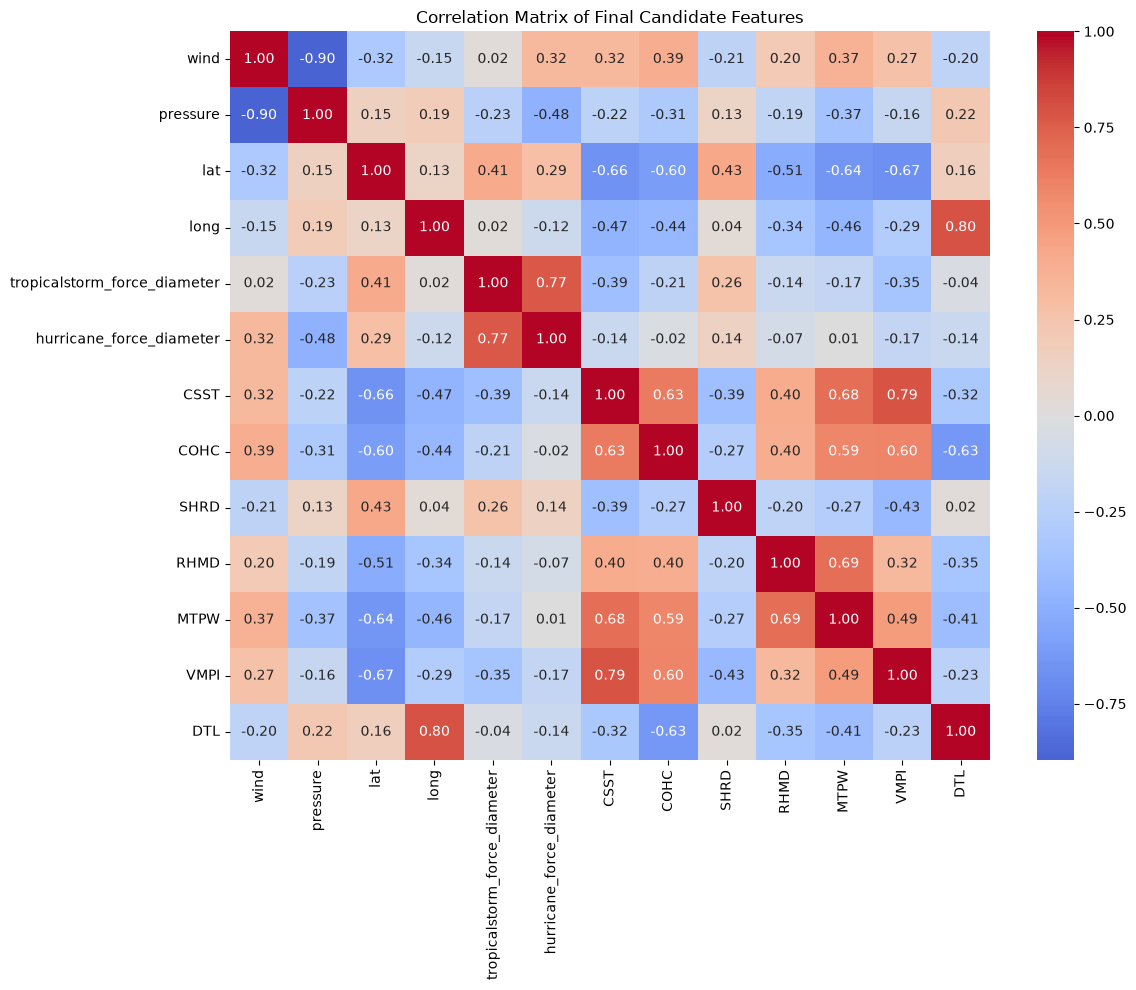

,correlation_with_major_hurricane
wind,0.848955
COHC,0.353677
MTPW,0.324488
CSST,0.283323
VMPI,0.263258
hurricane_force_diameter,0.248498
RHMD,0.179041
tropicalstorm_force_diameter,0.020243
long,-0.135230
SHRD,-0.177999


In [ ]:
# ==========================================================
# Correlation Analysis: Final Modeling Features
# ==========================================================

# Create target variable if not already present
if "major_hurricane" not in modeling_dataset.columns:
    modeling_dataset["major_hurricane"] = (
        modeling_dataset["category"] >= 3
    ).astype(int)

# Final feature groups
hurdat_features = [
    "wind",
    "pressure",
    "lat",
    "long",
    "tropicalstorm_force_diameter",
    "hurricane_force_diameter"
]

ships_features = [
    "CSST",
    "COHC",
    "SHRD",
    "RHMD",
    "MTPW",
    "VMPI",
    "DTL"
]

final_features = hurdat_features + ships_features

final_features = [
    col for col in final_features
    if col in modeling_dataset.columns
]

# Missingness summary
feature_summary = pd.DataFrame({
    "missing_count": modeling_dataset[final_features].isna().sum(),
    "missing_percent": modeling_dataset[final_features].isna().mean() * 100,
    "mean": modeling_dataset[final_features].mean(),
    "std": modeling_dataset[final_features].std(),
    "min": modeling_dataset[final_features].min(),
    "max": modeling_dataset[final_features].max()
}).sort_values("missing_percent", ascending=False)

display(feature_summary)

# Correlation matrix
corr = modeling_dataset[final_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix of Final Candidate Features")
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = (
    modeling_dataset[final_features + ["major_hurricane"]]
    .corr()["major_hurricane"]
    .drop("major_hurricane")
    .sort_values(ascending=False)
)

display(target_corr.to_frame("correlation_with_major_hurricane"))

Key Findings: Among the SHIPS variables, ocean heat content (COHC), total precipitable water (MTPW), sea surface temperature (CSST), and maximum potential intensity (VMPI) showed the strongest positive relationships with major hurricanes. Mid-level humidity (RHMD) had a weaker positive relationship, while vertical wind shear (SHRD) and distance to land (DTL) were negatively correlated, indicating that higher wind shear and storms closer to land are generally associated with a lower likelihood of becoming a major hurricane. 